## 🏠 Boston House Price Prediction ###

### This notebook demonstrates the development and comparison of regression models to predict housing prices in Boston based on various socio-economic and geographic features.

### Description 
This dataset contains information about housing prices in Boston and is often used for regression analysis and predictive modeling. The dataset is based on the classic Boston Housing dataset, which is frequently used as a benchmark in machine learning.

## Attributes:

1.) **CRIM** (Per Capita Crime Rate): The per capita crime rate in the neighborhood.

2.) **ZN** (Proportion of Residential Land Zoned for Large Lots): The proportion of residential land zoned for lots over 25,000 sq. ft.

3.) **INDUS** (Proportion of Non-Retail Business Acres): The proportion of non-retail business acres per town.

4.) **CHAS** (Charles River Dummy Variable): A binary variable indicating whether the Charles River bounds the tract (1 if bounded, 0 otherwise).

5.) **NOX** (Nitric Oxides Concentration): Nitric oxides concentration (parts per 10 million).

6.) **RM** (Average Number of Rooms per Dwelling): The average number of rooms per dwelling.

7.) **AGE** (Proportion of Owner-Occupied Units Built Prior to 1940): The proportion of owner-occupied units built prior to 1940.

8.) **DIS** (Weighted Distances to Employment Centers): Weighted distances to five Boston employment centers.

9.) **RAD** (Index of Accessibility to Radial Highways): An index representing accessibility to radial highways.

10.) **TAX** (Full-Value Property Tax Rate per $10,000): The full-value property tax rate per $10,000.

11.) **PTRATIO** (Pupil-Teacher Ratio): The pupil-teacher ratio by town.

12.) **B** (1000(Bk - 0.63)^2 where Bk is the Proportion of Black Residents): A measure of the proportion of Black residents adjusted for an offset.

13.) **LSTAT** (Percentage of Lower Status of the Population): The percentage of lower-status residents in the population.

14.) **MEDV** (Median Value of Owner-Occupied Homes): The median value of owner-occupied homes in $1000s (Target Variable).


To Predict the median value of owner-occupied homes (MEDV) based on various features to gain insights into factors influencing housing prices.



## Importing libraries

In [115]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [116]:
df=pd.read_csv('BostonHousing.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [117]:
df.duplicated().sum()

np.int64(0)

In [118]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [120]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


##### There are no duplicates and missing values in the dataset

### Checking correlation of various variables with each other and analyzing their impact on the output variable , i.e , medv.

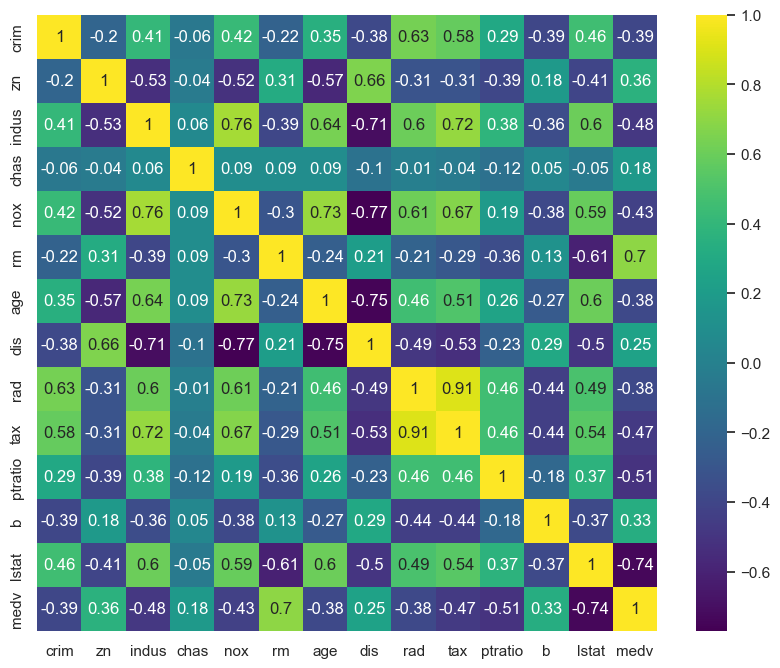

In [121]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr().round(2),annot=True,cmap='viridis') 
plt.show()

# Visulalization

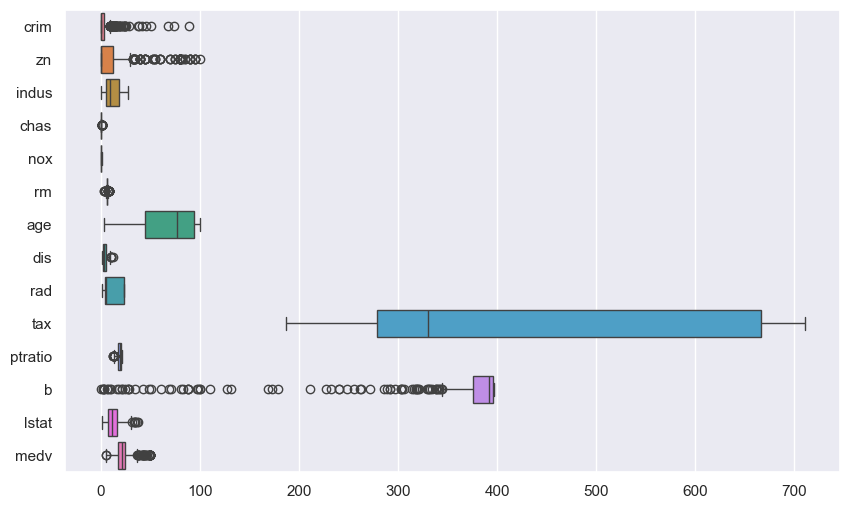

In [122]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, orient='h')
plt.show()

##### Outliers are present but not good to treat them as it will lead to removal of important information

### Check unique data in every column

In [123]:
for i in df.columns:
    print("********************************************************************************************")
    print(i)
    print(set(df[i].tolist()))

********************************************************************************************
crim
{0.15876, 0.08826, 2.36862, 2.33099, 4.0974, 1.27346, 0.65665, 0.12744, 1.20742, 2.37934, 1.15172, 2.3004, 8.98296, 5.20177, 13.5222, 6.53876, 9.2323, 8.26725, 11.1081, 18.4982, 19.6091, 15.288, 17.8667, 23.6482, 15.8744, 20.0849, 24.3938, 22.5971, 25.0461, 24.8017, 28.6558, 25.9406, 0.07165, 0.1029, 37.6619, 38.3518, 41.5292, 45.7461, 9.91655, 51.1358, 11.5779, 0.08873, 0.6147, 0.09178, 0.09849, 0.06724, 0.05023, 67.9208, 13.6781, 73.5341, 15.1772, 0.05497, 4.55587, 4.03841, 88.9762, 5.70818, 0.11747, 0.07151, 0.11069, 0.04819, 0.02731, 0.09164, 0.06588, 0.07022, 0.29819, 0.09103, 0.06466, 0.26938, 0.10574, 0.03768, 0.0187, 0.07503, 0.03578, 0.06642, 0.13117, 0.18159, 1.6566, 14.4383, 0.04981, 0.0351, 4.87141, 0.12329, 7.75223, 0.08221, 0.04113, 0.57529, 0.75026, 0.84054, 0.12932, 1.41385, 0.537, 0.33045, 0.55007, 2.37857, 0.51183, 4.81213, 0.09068, 7.36711, 9.59571, 0.03306, 0.49298, 3.6

In [124]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
crim,506.0,3.61,8.60,0.01,0.08,0.26,3.68,88.98
zn,506.0,11.36,23.32,0.00,0.00,0.00,12.50,100.00
indus,506.0,11.14,6.86,0.46,5.19,9.69,18.10,27.74
chas,506.0,0.07,0.25,0.00,0.00,0.00,0.00,1.00
nox,506.0,0.55,0.12,0.38,0.45,0.54,0.62,0.87
rm,506.0,6.28,0.70,3.56,5.89,6.21,6.62,8.78
age,506.0,68.57,28.15,2.90,45.02,77.50,94.07,100.00
dis,506.0,3.80,2.11,1.13,2.10,3.21,5.19,12.13
rad,506.0,9.55,8.71,1.00,4.00,5.00,24.00,24.00
tax,506.0,408.24,168.54,187.00,279.00,330.00,666.00,711.00


# Dividing the features into independent and dependent variable

In [125]:
x=df.drop('medv',axis=1)
y=df['medv']

In [126]:
x.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


In [127]:
y.head()

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: medv, dtype: float64

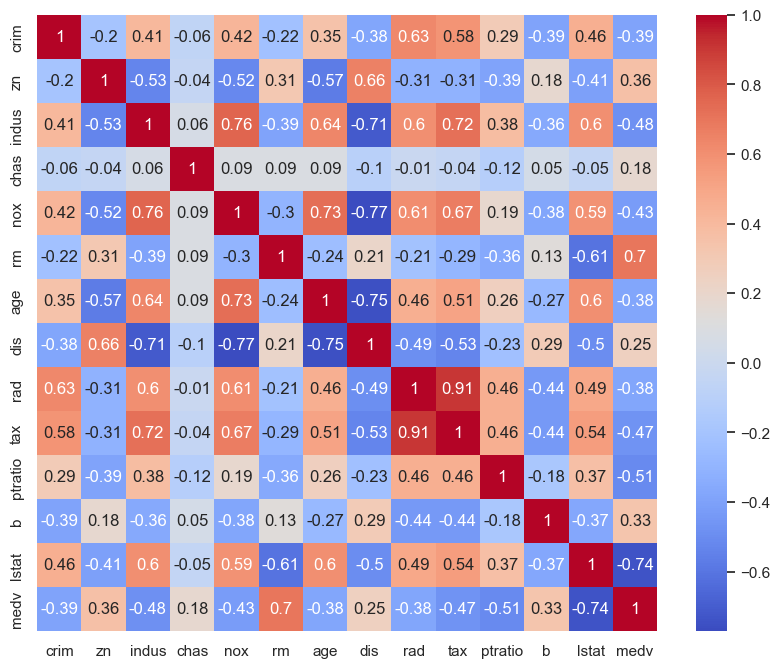

In [128]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr().round(2),annot=True,cmap='coolwarm') 
plt.show()

# Building the model 

### Splitting the data into train and test 

In [129]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2 , random_state=42)

### Checking skewness

In [130]:
from scipy.stats import skew

In [131]:
numeric_features = x_train.select_dtypes(include=['float64', 'int64']).columns

numeric_features = numeric_features.drop('chas')  # exclude categorical - chas is binary -0/1

skew_vals = df[numeric_features].skew()
skewed_features = skew_vals[abs(skew_vals) > 0.5].index.tolist()
skewed_features

['crim', 'zn', 'nox', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']

#### chas  — binary variable (0/1), transformation not applicable


In [132]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

x_train[skewed_features] = pt.fit_transform(x_train[skewed_features])
x_test[skewed_features] = pt.transform(x_test[skewed_features])

In [133]:
x_train[skewed_features]

,crim,zn,nox,age,dis,rad,tax,ptratio,b,lstat
477,1.632418,-0.611431,0.660141,1.088457,-0.820579,1.470669,1.398237,0.879939,-0.660366,1.519160
15,0.005892,-0.611431,0.016667,-0.535803,0.613586,-0.509927,-0.430816,1.429752,0.594880,-0.422094
332,-0.989911,1.645267,-1.118418,-1.560845,1.281746,-2.286892,-0.459128,-0.799009,-0.354822,-0.548273
423,1.441477,-0.611431,0.660141,0.568585,-0.894412,1.470669,1.398237,0.879939,-2.788304,1.387242
19,0.106125,-0.611431,0.016667,-0.055165,0.305059,-0.509927,-0.430816,1.429752,0.447936,0.056144
...,...,...,...,...,...,...,...,...,...,...
106,-0.673113,-0.611431,-0.160331,0.855059,-0.721840,-0.222363,0.176335,1.357553,0.596479,0.962458
270,-0.435557,1.582314,-0.784248,-1.020469,0.585628,-0.889170,-1.431685,-0.042918,0.377312,0.303307
348,-1.042367,1.698627,-1.157457,-1.390408,1.643349,-0.509927,-0.702047,-0.760223,0.447626,-0.961807
435,1.570571,-0.611431,1.443815,0.971118,-0.798663,1.470669,1.398237,0.879939,-2.759878,1.385566


In [134]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [135]:
def calculate_vif(X):
    vif = pd.DataFrame()
    vif["Features"] = X.columns

    vif["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    return vif.sort_values(by="VIF", ascending=False)

In [136]:
while True:
    vif_df = calculate_vif(x_train)
    max_vif = vif_df.iloc[0]["VIF"]

    if max_vif < 5:
        break

    drop_feature = vif_df.iloc[0]["Features"]
    print("Dropping:", drop_feature)

    x_train = x_train.drop(columns=[drop_feature])
    x_test = x_test.drop(columns=[drop_feature])

Dropping: indus
Dropping: crim
Dropping: nox


# Scaling

In [137]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [138]:
#%pip install statsmodels

In [139]:
#%pip install xgboost

# Building model

In [140]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import VotingRegressor,RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score

            Methods used  R2_score        MSE      RMSE       MAE      MAPE
0       LinearRegression  0.715729  20.846661  4.565814  2.935608  0.153368
1                  Ridge  0.715738  20.845990  4.565741  2.935031  0.153340
2                  Lasso  0.716383  20.798710  4.560560  2.883824  0.150093
3             ElasticNet  0.714926  20.905551  4.572259  2.827985  0.147547
4  DecisionTreeRegressor  0.645474  25.998725  5.098895  3.108824  0.176344
5  RandomForestRegressor  0.855440  10.601119  3.255936  2.214853  0.124299
6           XGBRegressor  0.875716   9.114246  3.018981  2.031556  0.120981
7    KNeighborsRegressor  0.745309  18.677482  4.321745  2.454902  0.126074
8                    SVR  0.707013  21.485822  4.635280  2.525764  0.132538
9        VotingRegressor  0.822671  13.004181  3.606131  2.217913  0.115335
Axes(0.125,0.11;0.775x0.77)


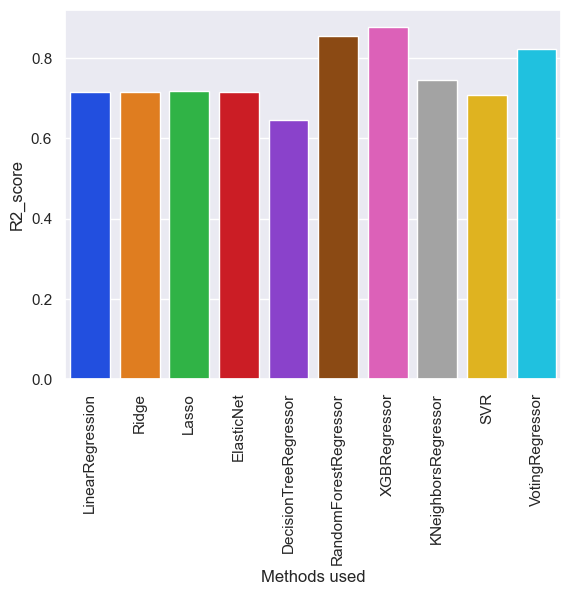

In [141]:
LR = LinearRegression()
LR.fit(x_train_scaled, y_train)
y_pred_test = LR.predict(x_test_scaled)

r2_LR = r2_score(y_test, y_pred_test)
mse_LR = mean_squared_error(y_test, y_pred_test)
rmse_LR = np.sqrt(mse_LR)
mae_LR = mean_absolute_error(y_test, y_pred_test)
mape_LR = mean_absolute_percentage_error(y_test, y_pred_test)


Rid = Ridge(alpha=0.1)
Rid.fit(x_train_scaled, y_train)
y_pred_test = Rid.predict(x_test_scaled)

r2_Rid = r2_score(y_test, y_pred_test)
mse_Rid = mean_squared_error(y_test, y_pred_test)
rmse_Rid = np.sqrt(mse_Rid)
mae_Rid = mean_absolute_error(y_test, y_pred_test)
mape_Rid = mean_absolute_percentage_error(y_test, y_pred_test)


Las = Lasso(alpha=0.1)
Las.fit(x_train_scaled, y_train)
y_pred_test = Las.predict(x_test_scaled)

r2_Las = r2_score(y_test, y_pred_test)
mse_Las = mean_squared_error(y_test, y_pred_test)
rmse_Las = np.sqrt(mse_Las)
mae_Las = mean_absolute_error(y_test, y_pred_test)
mape_Las = mean_absolute_percentage_error(y_test, y_pred_test)


Elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
Elastic.fit(x_train_scaled, y_train)
y_pred_test = Elastic.predict(x_test_scaled)

r2_Elastic = r2_score(y_test, y_pred_test)
mse_Elastic = mean_squared_error(y_test, y_pred_test)
rmse_Elastic = np.sqrt(mse_Elastic)
mae_Elastic = mean_absolute_error(y_test, y_pred_test)
mape_Elastic = mean_absolute_percentage_error(y_test, y_pred_test)


dtree = DecisionTreeRegressor(random_state=42)
dtree.fit(x_train_scaled, y_train)
y_pred_test = dtree.predict(x_test_scaled)

r2_dtree = r2_score(y_test, y_pred_test)
mse_dtree = mean_squared_error(y_test, y_pred_test)
rmse_dtree = np.sqrt(mse_dtree)
mae_dtree = mean_absolute_error(y_test, y_pred_test)
mape_dtree = mean_absolute_percentage_error(y_test, y_pred_test)


rfc = RandomForestRegressor(random_state=42)
rfc.fit(x_train_scaled, y_train)
y_pred_test = rfc.predict(x_test_scaled)

r2_rfc = r2_score(y_test, y_pred_test)
mse_rfc = mean_squared_error(y_test, y_pred_test)
rmse_rfc = np.sqrt(mse_rfc)
mae_rfc = mean_absolute_error(y_test, y_pred_test)
mape_rfc = mean_absolute_percentage_error(y_test, y_pred_test)


xgb = XGBRegressor()
xgb.fit(x_train_scaled, y_train)
y_pred_test = xgb.predict(x_test_scaled)

r2_xgb = r2_score(y_test, y_pred_test)
mse_xgb = mean_squared_error(y_test, y_pred_test)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_test)
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_test)


KNC = KNeighborsRegressor()
KNC.fit(x_train_scaled, y_train)
y_pred_test = KNC.predict(x_test_scaled)

r2_KNC = r2_score(y_test, y_pred_test)
mse_KNC = mean_squared_error(y_test, y_pred_test)
rmse_KNC = np.sqrt(mse_KNC)
mae_KNC = mean_absolute_error(y_test, y_pred_test)
mape_KNC = mean_absolute_percentage_error(y_test, y_pred_test)


svm = SVR()
svm.fit(x_train_scaled, y_train)
y_pred_test = svm.predict(x_test_scaled)

r2_svm = r2_score(y_test, y_pred_test)
mse_svm = mean_squared_error(y_test, y_pred_test)
rmse_svm = np.sqrt(mse_svm)
mae_svm = mean_absolute_error(y_test, y_pred_test)
mape_svm = mean_absolute_percentage_error(y_test, y_pred_test)

voc = VotingRegressor([
    ('LR', LR),
    ('Rid', Rid),
    ('Las', Las),
    ('Elastic', Elastic),
    ('dtree', dtree),
    ('rfc', rfc),
    ('xgb', xgb),
    ('KNC', KNC),
    ('svm', svm)
])

voc.fit(x_train_scaled, y_train)

y_pred_test = voc.predict(x_test_scaled)

r2_voc = r2_score(y_test, y_pred_test)
mse_voc = mean_squared_error(y_test, y_pred_test)
rmse_voc = np.sqrt(mse_voc)
mae_voc = mean_absolute_error(y_test, y_pred_test)
mape_voc = mean_absolute_percentage_error(y_test, y_pred_test)

list1=['LinearRegression','Ridge','Lasso','ElasticNet','DecisionTreeRegressor','RandomForestRegressor','XGBRegressor','KNeighborsRegressor','SVR','VotingRegressor']
list2=[r2_LR,r2_Rid,r2_Las,r2_Elastic,r2_dtree,r2_rfc,r2_xgb,r2_KNC,r2_svm,r2_voc]
list3=[mse_LR,mse_Rid,mse_Las,mse_Elastic,mse_dtree,mse_rfc,mse_xgb,mse_KNC,mse_svm,mse_voc]
list4=[rmse_LR,rmse_Rid,rmse_Las,rmse_Elastic,rmse_dtree,rmse_rfc,rmse_xgb,rmse_KNC,rmse_svm,rmse_voc]
list5=[mae_LR,mae_Rid,mae_Las,mae_Elastic,mae_dtree,mae_rfc,mae_xgb,mae_KNC,mae_svm,mae_voc]
list6=[mape_LR,mape_Rid,mape_Las,mape_Elastic,mape_dtree,mape_rfc,mape_xgb,mape_KNC,mape_svm,mape_voc]

df_accuracy=pd.DataFrame({'Methods used':list1 , 'R2_score':list2 , "MSE":list3,"RMSE":list4,"MAE":list5,"MAPE":list6})
print(df_accuracy)

unique_colors = sns.color_palette("bright", len(df_accuracy))

chart=sns.barplot(x="Methods used" , y="R2_score" , data=df_accuracy,palette=unique_colors)
chart.set_xticklabels(chart.get_xticklabels(),rotation=90)
print(chart)

# Observations

In [142]:
xgb = XGBRegressor(
    n_estimators  = 180,
    max_depth     = 3,
    learning_rate = 0.1,   
    subsample     = 0.6,   
    random_state  = 42,
    verbosity     = 0
)

xgb.fit(x_train_scaled, y_train)

r2_xgb_train = r2_score(y_train, xgb.predict(x_train_scaled))
r2_xgb_test  = r2_score(y_test,  xgb.predict(x_test_scaled))

print('Train R² Score :', round(r2_xgb_train, 4))
print('Test R²  Score :', round(r2_xgb_test,  4))
print('Overfit Gap    :', round(r2_xgb_train - r2_xgb_test, 4))

Train R² Score : 0.9832
Test R²  Score : 0.8882
Overfit Gap    : 0.095


Final XGBoost params: n_estimators=180, max_depth=3, 
learning_rate=0.1, subsample=0.6

Train R² : 0.9832
Test R²  : 0.8882
Gap      : 0.095

Note: Overfitting gap of ~10% is expected on a small dataset of 506 rows.
The model generalises well with Test R² of 0.888.
Reducing n_estimators lowers the gap but also reduces Test R² — 
0.888 represents the best generalisation performance achieved.

In [143]:
from sklearn.model_selection import cross_val_score
import numpy as np

training = cross_val_score(xgb, x_train_scaled, y_train, cv=10, scoring='r2')

print("CV R² Scores     :", training.round(4))
print("Mean CV R² Score :", round(training.mean(), 4))
print("Std Dev          :", round(training.std(), 4))

CV R² Scores     : [0.8032 0.9102 0.8999 0.6754 0.8629 0.8763 0.9052 0.9084 0.9325 0.6995]
Mean CV R² Score : 0.8473
Std Dev          : 0.0869


In [147]:
from joblib import dump
from sklearn.preprocessing import StandardScaler

features = ['zn','chas','rm','age','dis','rad','tax','ptratio','b','lstat']

x_train = x_train[features]
x_test  = x_test[features]

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

xgb.fit(x_train_scaled, y_train)

dump(scaler, 'scaler.joblib')
dump(xgb, 'model_XGBoost.joblib')

print("Training done correctly")

Training done correctly


In [148]:
df_accuracy.to_csv("model_metrics.csv", index=False)
print("model_metrics.csv saved.")

model_metrics.csv saved.
